# AHP vs Fuzzy AHP Ranking Comparison - Sample Development Pipeline

## Decision Support Stage

This notebook compares sample-development AHP and Fuzzy AHP outputs. It verifies comparison mechanics only; it does not produce final ranking conclusions.

**Important:** all outputs are `sample_development_only` and `not_final_expert_judgement`.

## Comparison Objective

The comparison checks whether AHP and Fuzzy AHP produce similar weights and ranks for the same five SentiRank criteria. Real interpretation must wait until validated expert judgements are available.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "ml-service").exists()
            and (candidate / "datasets").exists()
            and (candidate / "docs").exists()
        ):
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
TEMPLATE_DIR = PROJECT_ROOT / "docs" / "templates" / "ahp"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ML_SERVICE_DIR:", ML_SERVICE_DIR)

PROJECT_ROOT: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank
ML_SERVICE_DIR: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service


In [2]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing JSON: {path}")
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def load_csv(path: Path):
    if not path.exists():
        print(f"Missing CSV: {path}")
        return None
    return pd.read_csv(path)


def display_image(path: Path) -> None:
    if not path.exists():
        print(f"Missing figure: {path}")
        return
    display(Image(filename=str(path)))


def run_ml_script(script_name: str) -> None:
    command = [sys.executable, "scripts/" + script_name]
    result = subprocess.run(
        command,
        cwd=ML_SERVICE_DIR,
        text=True,
        capture_output=True,
        check=False,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Script failed: {script_name}")

## Load Source Weights

The comparison script expects sample AHP and Fuzzy AHP weight JSON files generated by notebooks 06 and 07 or by the corresponding scripts.

In [3]:
AHP_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "06_ahp" / "sample_development"
FUZZY_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "07_fuzzy_ahp" / "sample_development"
COMPARISON_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "08_ranking_comparison" / "sample_development"
COMPARISON_FIGURE_DIR = PROJECT_ROOT / "docs" / "figures" / "08_ranking_comparison" / "sample_development"

ahp_weights = load_json(AHP_OUTPUT_DIR / "ahp_weights_sample_development.json")
fuzzy_weights = load_json(FUZZY_OUTPUT_DIR / "fuzzy_ahp_weights_sample_development.json")
if ahp_weights:
    display(pd.DataFrame(ahp_weights["weights"]).sort_values("rank"))
if fuzzy_weights:
    fuzzy_df = pd.DataFrame(fuzzy_weights["weights"])
    display(fuzzy_df.sort_values("rank"))

,criterion_id,criterion_name,weight,rank,run_label,is_sample,not_final_expert_judgement
1,C2,App Reliability & Usability,0.529412,1,sample_development_only,True,True
0,C1,"Features, Content & Audio Experience",0.176471,2,sample_development_only,True,True
3,C4,Subscription & Pricing,0.176471,3,sample_development_only,True,True
2,C3,Ads Experience,0.058824,4,sample_development_only,True,True
4,C5,Account/Login,0.058824,5,sample_development_only,True,True


,criterion_id,criterion_name,fuzzy_weight,defuzzified_weight,normalized_weight,rank,run_label,is_sample,not_final_expert_judgement
1,C2,App Reliability & Usability,"{'l': 0.3685903730696601, 'm': 0.5294117647058...",0.541493,0.519544,1,sample_development_only,True,True
0,C1,"Features, Content & Audio Experience","{'l': 0.12158947827503719, 'm': 0.176470588235...",0.186891,0.179316,2,sample_development_only,True,True
3,C4,Subscription & Pricing,"{'l': 0.12158947827503719, 'm': 0.176470588235...",0.186891,0.179316,3,sample_development_only,True,True
2,C3,Ads Experience,"{'l': 0.04500113800856217, 'm': 0.058823529411...",0.063485,0.060912,4,sample_development_only,True,True
4,C5,Account/Login,"{'l': 0.04500113800856217, 'm': 0.058823529411...",0.063485,0.060912,5,sample_development_only,True,True


## Run Sample AHP vs Fuzzy AHP Comparison

This cell writes only to `datasets/outputs/eda/08_ranking_comparison/sample_development/`. It does not create final ranking comparison outputs.

In [4]:
run_ml_script("compare_ahp_fuzzy_outputs.py")

Sample AHP/Fuzzy comparison written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\08_ranking_comparison\sample_development\ahp_fuzzy_ranking_comparison_sample_development.json
Changed rank count: 0
Sample comparison figure written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\docs\figures\08_ranking_comparison\sample_development\ahp_fuzzy_weight_comparison_sample_development.png



## Sample Comparison Outputs

In [5]:
comparison_df = load_csv(COMPARISON_OUTPUT_DIR / "ahp_fuzzy_ranking_comparison_sample_development.csv")
if comparison_df is not None:
    display(comparison_df.sort_values("ahp_rank"))

summary = load_json(COMPARISON_OUTPUT_DIR / "ranking_comparison_summary_sample_development.json")
if summary:
    display(pd.DataFrame([summary["summary"]]))

,criterion_id,criterion_name,ahp_weight,fuzzy_ahp_weight,ahp_rank,fuzzy_ahp_rank,weight_delta,rank_delta,run_label,is_sample,not_final_expert_judgement
0,C2,App Reliability & Usability,0.529412,0.519544,1,1,-0.009868,0,sample_development_only,True,True
1,C1,"Features, Content & Audio Experience",0.176471,0.179316,2,2,0.002846,0,sample_development_only,True,True
2,C4,Subscription & Pricing,0.176471,0.179316,3,3,0.002846,0,sample_development_only,True,True
3,C3,Ads Experience,0.058824,0.060912,4,4,0.002088,0,sample_development_only,True,True
4,C5,Account/Login,0.058824,0.060912,5,5,0.002088,0,sample_development_only,True,True


,total_criteria,max_absolute_weight_delta,changed_rank_count,identical_top_rank
0,5,0.009868,0,True


## Sample Comparison Figure

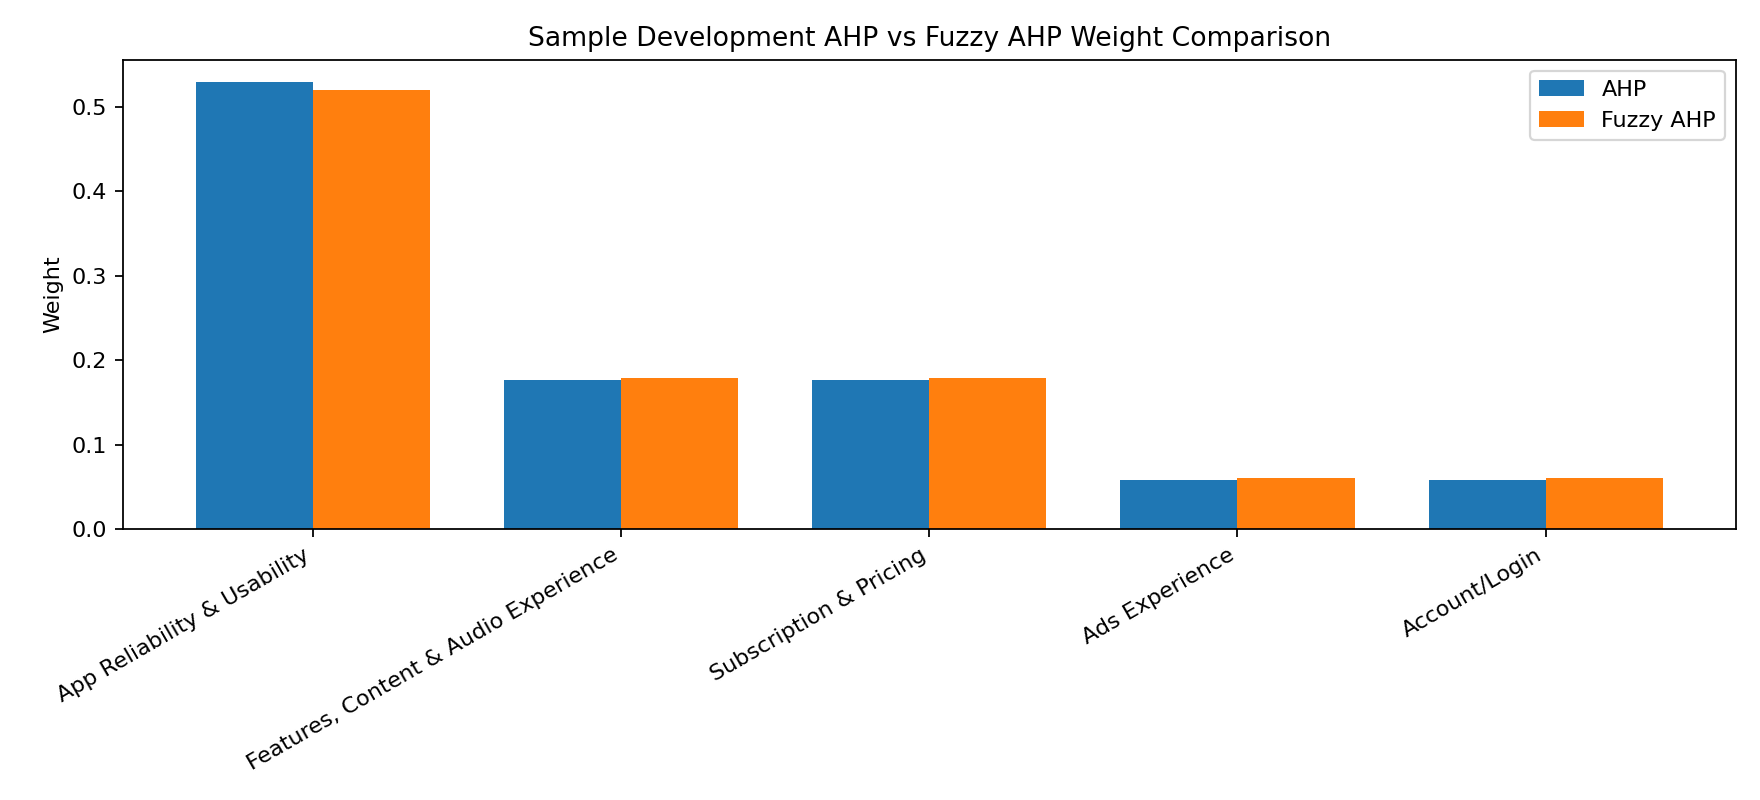

In [6]:
display_image(COMPARISON_FIGURE_DIR / "ahp_fuzzy_weight_comparison_sample_development.png")

## Interpretation Notes

- This sample comparison verifies output compatibility between AHP and Fuzzy AHP.
- Rank and weight differences here are not research findings because the input judgements are synthetic.
- Final ranking comparison will be performed later using real expert judgement.

## Phase 10D Planning Note

AHP vs Fuzzy AHP ranking comparison should use final calculated AHP and Fuzzy AHP weights only after expert judgement files have passed validation and multi-expert aggregation. The current sample-development comparison remains a workflow check, not a final thesis result.